# Canada Food CPI — CFPR Replica Experiment

**Core question:** of the methods evaluated here, which one should we trust to
produce the per-category forecast for the next Canada's Food Price Report?

This notebook runs a multi-predictor backtest against the canonical CFPR spec
(annual July origins 2009–2024, 12-step trajectory, all 9 StatCan food
sub-indices) and answers that question via per-category model selection on CRPS
and MAPE.

**What's here:**

1. Data overview — nine food CPI sub-indices at a glance.
2. Spec + predictors — loaded from YAML; backtest results cached on disk.
3. Qualitative check — trajectory fans and avg/avg YoY grid.
4. Model selection — CRPS and MAPE per category; per-category winner table.
5. Protected eval — budget-enforced holdout (commented out; spend deliberately).


---
## 1. Setup

The heavy lifting lives in helper modules alongside this notebook:

- `data.py`      registers the 9 StatCan series on a `DataService`.
- `analysis.py`  flattens results to DataFrames and computes avg/avg YoY.
- `plots.py`     renders the figures the CFPR audience expects.
- `reference_specs/food_cpi/food_cpi_cfpr_{backtest,eval}.yaml` are the specs.

Run the data fetch once if you haven't:

```bash
uv run python scripts/fetch_cpi.py
```


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import yaml
from dotenv import load_dotenv


warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve().parents[1]
load_dotenv(ROOT / ".env")

from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
    MultiTargetEvalSpec,
    cached_multi_backtest,
    describe_spec,
)
from aieng.forecasting.evaluation.eval import EvalTracker
from aieng.forecasting.methods import DartsAutoARIMAPredictor, LastValuePredictor
from food_price_forecasting.analysis import compute_ape_long, compute_avgyoy, compute_mape, summarize_crps
from food_price_forecasting.data import CATEGORY_LABELS, build_food_cpi_service
from food_price_forecasting.plots import (
    plot_avgyoy_grid,
    plot_food_cpi_small_multiples,
    plot_mape_by_category,
    plot_trajectory_fan,
)


STATCAN_CACHE = ROOT / "data" / "statcan"
PREDICTIONS_DIR = ROOT / "data" / "predictions"
EVAL_RUNS_PATH = ROOT / "data" / "eval_runs.yaml"
SPECS_DIR = ROOT / "reference_specs" / "food_cpi"

svc = build_food_cpi_service(cache_dir=STATCAN_CACHE)
print(f"Registered {len(CATEGORY_LABELS)} food CPI series.")

Registered 9 food CPI series.


---
## 2. Data exploration

A single figure is plenty — the nine sub-indices track each other closely with
a clear post-2020 acceleration.

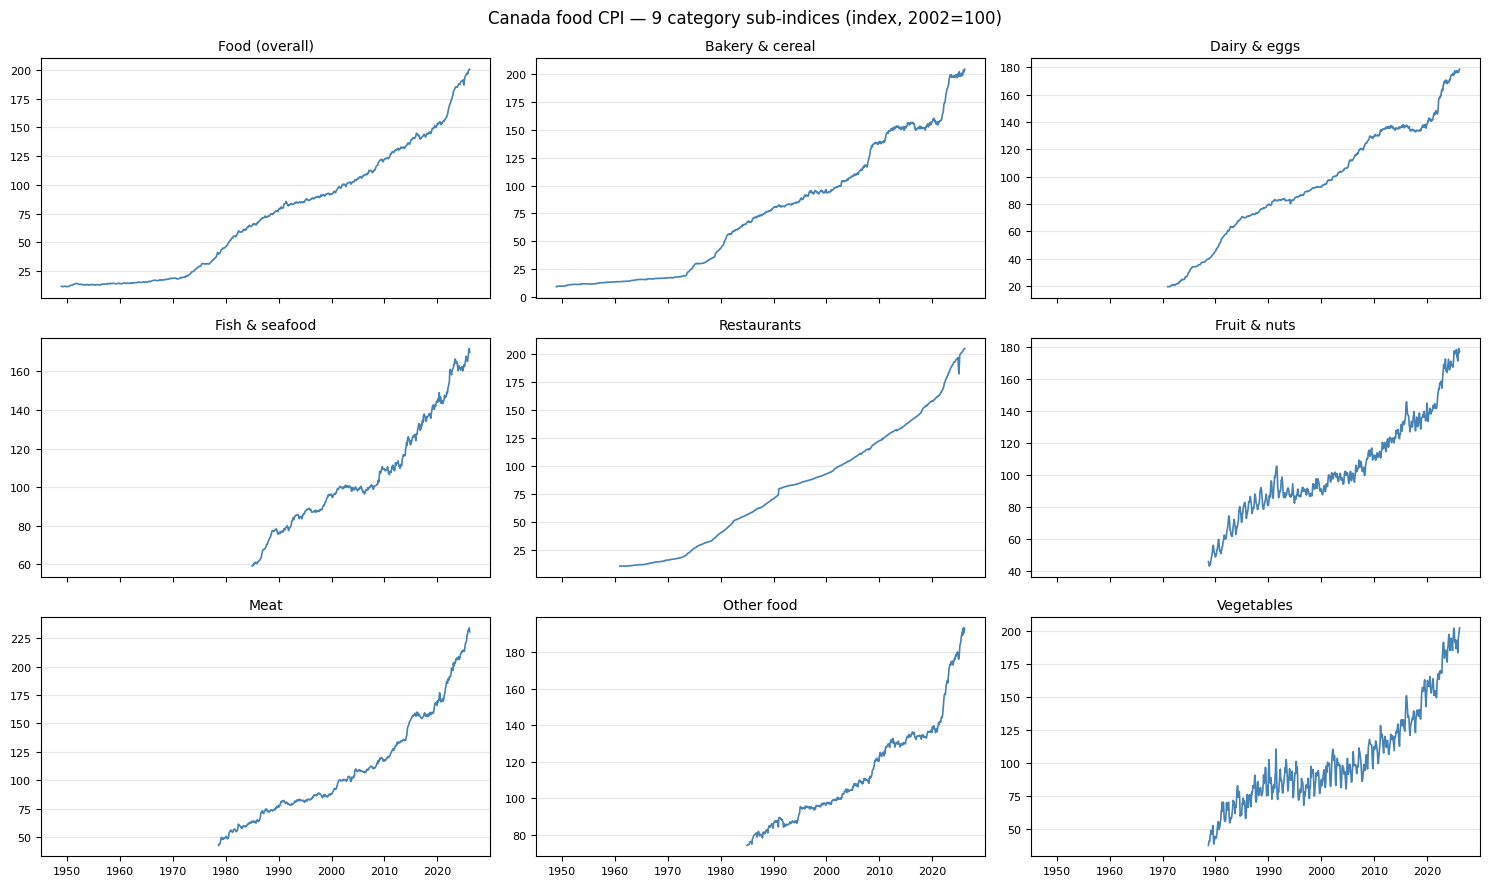

In [2]:
fig, _ = plot_food_cpi_small_multiples(svc)
plt.show()

---
## 3. The canonical CFPR task

The backtest spec is loaded from YAML so the spec (not the notebook) is the
source of truth.  `describe_spec()` renders a plain-text summary suitable for
print, prompts, or documentation.

In [3]:
with (SPECS_DIR / "food_cpi_cfpr_backtest.yaml").open() as f:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(f))

print(describe_spec(backtest_spec, data_service=svc))
print(
    f"\nTasks: {len(backtest_spec.tasks)}  Window: {backtest_spec.start.date()} → {backtest_spec.end.date()}  Stride: {backtest_spec.stride}"
)

MultiTargetBacktestSpec (spec_id=food_cpi_cfpr_backtest)
  description: CFPR replica backtest: 9 Canadian food CPI sub-indices, annual July origins 2009-2024, 12-step trajectory (horizons 6-17) spanning Jan-Dec of the following calendar year.  Supports computation of the canonical average-over-average YoY CPI change that the Canada's Food Price Report publishes each year.  Open resource — run freely.
  start:       2009-07-01 00:00:00
  end:         2024-07-01 00:00:00
  stride:      12
  warmup:      24
  tasks:       9

Task: food_cpi_overall_cfpr
  description: Canada CPI Food (overall, 2002=100), trajectory across Jan-Dec of the year following a July origin.
  horizons:    [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] (len=12)
  frequency:   MS
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: cpi_food_canada
    description:    CPI Food (overall), Canada (2002=100)
    source:         Statistics Canada
    units:          Index 2002=100
    frequency:      M

---
## 4. Predictors

Five predictors, each implementing the same `Predictor` API against the same
spec.  Extend the `all_predictors` list or swap in your own subclass to run it
through the full evaluation loop.

- `LastValuePredictor` — repeats the last observed value with a fixed narrow
  spread.  Cheap, zero-configuration, hard to beat on very short horizons.
- `DartsAutoARIMAPredictor` — auto-ARIMA via Darts; fits a new model at each origin.
- `ContinuousLLMPredictor` (×2) — direct LLM call that emits a structured JSON trajectory; no tools, no search.
- `AgentPredictor` — drives the food CPI analyst agent through the ADK runner.  Domain context comes from the ADK `forecast-food-cpi` skill (L1 frontmatter + `load_skill`); the forecaster instruction does not duplicate skill names.

### Agent instantiation: three patterns

`AgentConfig` captures the agent's **identity** — instruction, model, skills, capability toggles.  
`AgentPredictor` captures the agent's **role** — which output schema it must satisfy in this particular experiment.  
The same config object can be re-used across all three patterns:

**Pattern 1 — experiment predictor (one-liner)**

```python
predictor = build_food_price_agent_predictor(model="gemini-3-flash-preview")
```

**Pattern 2 — explicit construction (shows the identity/role split)**

```python
from aieng.forecasting.methods.agentic import AgentPredictor, ContinuousAgentForecastOutput
from food_price_forecasting.analyst_agent import (
    FoodPriceForecastPromptBuilder,
    build_food_price_agent_config,
)

config = build_food_price_agent_config(model="gemini-3-flash-preview")  # identity
predictor = AgentPredictor(                                              # role
    config,
    FoodPriceForecastPromptBuilder(),
    output_schema=ContinuousAgentForecastOutput,
)
```

**Pattern 3 — interactive analyst via `adk web` (free-form, no output schema)**

```bash
# From the repo root — launches a chat UI against the agent with no JSON constraint.
uv run adk web implementations/food_price_forecasting/analyst_agent
```

This works because `analyst_agent/agent.py` exposes a `root_agent` attribute via
`__getattr__` that calls `build_adk_agent(config)` with no `output_schema`.

### Context agent (`enable_news_search`)

The forecaster may attach a **`context_agent`** tool (bounded Google Search sub-agent). It is
configured at **predictor build time** via `enable_news_search` — not part of the
`forecast-food-cpi` skill.

- **`ENABLE_NEWS_SEARCH = False`** (predictors cell below) — default for backtests; avoids
  future-information leakage on historical `as_of` dates.
- Set to `True` to see `context_agent` invocations in Langfuse; only safe when `as_of` is
  the real present or you accept leakage risk.

The smoke cell uses a **separate** predictor with search **on** so backtest wiring stays off.

### Langfuse traces

When `LANGFUSE_PUBLIC_KEY` and `LANGFUSE_SECRET_KEY` are set in `.env`, `AgentPredictor`
exports ADK spans (tool calls, including `set_model_response`, `list_skills`, `load_skill`,
and `context_agent`) to Langfuse.

**Skills in Langfuse:** on the first turn, look for a **`list_skills`** tool call — the response
should include `forecast-food-cpi` and its description. Optionally find **`load_skill`** with
`skill_name=forecast-food-cpi` for the full domain brief (L2).

The cell below runs **one** agent `predict()` (full CFPR horizons 6–17, trimmed history)
with `context_agent` enabled, prints a plain-text forecast summary (with explicit
failure messages when output is empty or incomplete), and prints a Langfuse trace URL
when available.


In [4]:
import pandas as pd
from aieng.forecasting.methods import (
    ContinuousLLMPredictor,
    ContinuousLLMPredictorConfig,
)
from food_price_forecasting.analyst_agent import build_food_price_agent_predictor


gemini_2_5_flash_lite_predictor = ContinuousLLMPredictor(
    ContinuousLLMPredictorConfig(model="gemini/gemini-2.5-flash-lite", n_samples=3)
)
gemini_3_flash_predictor = ContinuousLLMPredictor(
    ContinuousLLMPredictorConfig(model="gemini/gemini-3-flash-preview", n_samples=3)
)
# gemini_3_1_flash_lite_predictor = ContinuousLLMPredictor(ContinuousLLMPredictorConfig(model="gemini/gemini-3.1-flash-lite", n_samples=1))
# gemini_3_1_pro_predictor = ContinuousLLMPredictor(ContinuousLLMPredictorConfig(model="gemini/gemini-3.1-pro-preview", n_samples=1))

# AgentPredictor: agentic forecaster using the food CPI analyst agent.
# context_agent (news search) is attached only when ENABLE_NEWS_SEARCH is True.
ENABLE_NEWS_SEARCH = False  # keep False for historical backtests (leakage risk)

food_agent_predictor = build_food_price_agent_predictor(
    model="gemini-3-flash-preview",
    enable_news_search=ENABLE_NEWS_SEARCH,
)
print(f"food_agent_predictor: context_agent={'enabled' if ENABLE_NEWS_SEARCH else 'disabled'}")

all_predictors = [
    LastValuePredictor(),
    DartsAutoARIMAPredictor(),
    gemini_2_5_flash_lite_predictor,
    gemini_3_flash_predictor,
    food_agent_predictor,
    # gemini_3_1_flash_lite_predictor,
    # gemini_3_1_pro_predictor,
]

PREDICTOR_COLORS: dict[str, str] = {
    "last_value_naive": "#7f7f7f",
    "darts_autoarima": "#1f77b4",
    gemini_2_5_flash_lite_predictor.predictor_id: "#d62728",
    gemini_3_flash_predictor.predictor_id: "#9467bd",
    food_agent_predictor.predictor_id: "#ff7f0e",
    # gemini_3_1_flash_lite_predictor.predictor_id: "#2ca02c",
    # gemini_3_1_pro_predictor.predictor_id: "#8c564b",
}

for p in all_predictors:
    print(f"  {p.predictor_id}")

food_agent_predictor: context_agent=disabled
  last_value_naive
  darts_autoarima
  llmp_continuous[gemini/gemini-2.5-flash-lite]
  llmp_continuous[gemini/gemini-3-flash-preview]
  agent_predictor_food_price_forecasting_agent_gemini-3-flash-preview_continuous


In [5]:
# Agent smoke: one predict() call, plain-text summary + Langfuse trace link.
# Requires GEMINI_API_KEY. Langfuse keys optional (LANGFUSE_PUBLIC_KEY / LANGFUSE_SECRET_KEY).
import logging
from datetime import datetime

from aieng.forecasting.evaluation.task import ForecastingTask
from aieng.forecasting.langfuse_tracing import init_langfuse_tracing, print_langfuse_trace_url
from food_price_forecasting.analyst_agent import (
    FoodPriceForecastPromptBuilder,
    build_food_price_agent_predictor,
)
from food_price_forecasting.data import build_food_cpi_service
from food_price_forecasting.smoke_report import CFPR_HORIZONS, summarize_agent_predictions
from pydantic import ValidationError

logging.basicConfig(level=logging.WARNING, format="%(message)s")

init_langfuse_tracing()

_AGENT_SMOKE_ORIGIN = datetime(2023, 7, 1)
_AGENT_SMOKE_TASK = ForecastingTask(
    task_id="meat_cfpr",
    target_series_id="cpi_meat_canada",
    horizons=CFPR_HORIZONS,
    frequency="MS",
    description="Meat CFPR; Jan–Dec trajectory from July origin.",
)

ENABLE_NEWS_SEARCH_SMOKE = True  # set False to skip news search (faster, no leakage risk)

_smoke_svc = build_food_cpi_service(cache_dir=STATCAN_CACHE)
_smoke_predictor = build_food_price_agent_predictor(
    model="gemini-3-flash-preview",
    enable_news_search=ENABLE_NEWS_SEARCH_SMOKE,
    prompt_builder=FoodPriceForecastPromptBuilder(max_history_rows=60),
)

print(f"smoke predictor: context_agent={'enabled' if ENABLE_NEWS_SEARCH_SMOKE else 'disabled'}")

_ctx = _smoke_svc.context(as_of=_AGENT_SMOKE_ORIGIN)
try:
    _smoke_preds = _smoke_predictor.predict(_AGENT_SMOKE_TASK, _ctx)
except ValidationError:
    print("\n✗ SCHEMA VALIDATION FAILED")
    print("  The model response did not match the structured forecast schema.")
    print("  See WARNING log above for the raw agent response.")
    _smoke_preds = []

summarize_agent_predictions(_smoke_preds, expected_horizons=CFPR_HORIZONS)
print_langfuse_trace_url()  # flushes spans and prints trace URL (or project page if id unavailable)

smoke predictor: context_agent=enabled


/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/authlib/_joserfc_helpers.py:8: AuthlibDeprecationWarning: authlib.jose module is deprecated, please use joserfc instead.
It will be compatible before version 2.0.0.
  from authlib.jose import ECKey
Task was destroyed but it is pending!
task: <Task pending name='Task-84' coro=<<async_generator_athrow without __name__>()>>
Failed to detach context
Traceback (most recent call last):
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/trace/__init__.py", line 589, in use_span
    yield span
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/openinference/instrumentation/_tracers.py", line 141, in start_as_current_span
    yield cast(OpenInferenceSpan, current_span)
GeneratorExit

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/p


✓ Well-formed fan: 12 predictions (horizons 6–17)

     Month     Point       q05       q50       q95  OK
    ──────     ─────       ───       ───       ───  ──
   2024-01    211.50    200.70    211.50    222.70  ok
   2024-02    211.10    199.60    211.10    223.20  ok
   2024-03    210.90    198.80    210.90    223.80  ok
   2024-04    214.90    202.00    214.90    228.90  ok
   2024-05    216.00    202.40    216.00    230.70  ok
   2024-06    217.10    202.80    217.10    232.50  ok
   2024-07    219.30    204.30    219.30    235.60  ok
   2024-08    219.30    203.70    219.30    236.30  ok
   2024-09    221.30    205.10    221.30    238.90  ok
   2024-10    221.50    204.70    221.50    239.80  ok
   2024-11    222.20    204.80    222.20    241.10  ok
   2024-12    221.50    203.80    221.50    240.80  ok

  Rationale:
    The forecast assumes that meat prices will continue to face upward
    pressure due to historically low cattle inventories and high production
    costs (feed, 

Context error: No active span in current context. Operations that depend on an active span will be skipped. Ensure spans are created with start_as_current_observation() or that you're operating within an active span context.
Context error: No active span in current context. Operations that depend on an active span will be skipped. Ensure spans are created with start_as_current_observation() or that you're operating within an active span context.


Langfuse: trace id not available in this process after flush.
  Open traces: https://us.cloud.langfuse.com/project/cmobssx3g00buad07gb4o1gh6/traces
  Filter by trace name: 'food_cpi_smoke_437cd193'


---
## 5. Backtest (cached on disk)

`cached_multi_backtest` writes each `BacktestResult` to
`data/predictions/<spec_id>/<predictor_id>/<task_id>.yaml` and reuses it on
subsequent runs.  Pass `force_refresh=True` to re-run a predictor from scratch.

All three predictors run against the same `food_cpi_cfpr_backtest` spec.
`ContinuousLLMPredictor` makes API calls on a first run (~144 calls at
`n_samples=3`); subsequent runs are free from cache.


In [ ]:
results_by_predictor: dict[str, dict[str, object]] = {}

for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results_by_predictor[predictor.predictor_id] = cached_multi_backtest(
        predictor=predictor,
        spec=backtest_spec,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )
    for task_id, result in results_by_predictor[predictor.predictor_id].items():
        print(f"  {task_id:42s}  mean CRPS = {result.mean_crps:.4f}  ({len(result.predictions)} preds)")

---
## 6. Trajectories — overall food CPI

For the overall Canadian food CPI, show the three most recent origins with each
predictor's 12-step trajectory fan.  Solid black is observed history, dashed
black is the Y+1 actuals where available, fans are the predictor's 90%/50%
intervals with the median in colour.

In [ ]:
FOCAL_TASK = "food_cpi_overall_cfpr"
FOCAL_SERIES = "cpi_food_canada"

fig, _ = plot_trajectory_fan(
    results_by_predictor=results_by_predictor,
    task_id=FOCAL_TASK,
    category_id=FOCAL_SERIES,
    data_service=svc,
    n_recent=3,
    colors=PREDICTOR_COLORS,
)
plt.show()

---
## 7. Avg/avg YoY — all 9 categories

The headline CFPR metric: for each July origin, mean predicted CPI for year Y+1
divided by mean observed CPI for year Y, minus 1.  Actual realised YoY (solid
black) is the out-of-sample truth for every completed year.

**Note on the 2022 spike:** LLMP with `reasoning_effort="disable"` anchors its
extrapolation on the *current level* rather than the *rate of change*, so it
tends to underestimate carry-through during a mid-surge origin.  This is a
known limitation of level-domain direct prompting (Gruver / CiK), not a
data-feeding issue.


In [ ]:
from datetime import datetime, timezone


yoy_by_predictor_by_task: dict[str, dict[str, object]] = {}
task_to_category: dict[str, str] = {task.task_id: task.target_series_id for task in backtest_spec.tasks}

_as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)

for pid, task_results in results_by_predictor.items():
    yoy_by_predictor_by_task[pid] = {}
    for task_id, result in task_results.items():
        actual_df = svc.get_series(result.spec.task.target_series_id, as_of=_as_of)
        yoy_by_predictor_by_task[pid][task_id] = compute_avgyoy(result, actual_df)

fig, _ = plot_avgyoy_grid(
    yoy_by_predictor_by_task=yoy_by_predictor_by_task,
    task_to_category=task_to_category,
    colors=PREDICTOR_COLORS,
)
plt.show()

---
## 8. Model selection

### 8.1 CRPS per category

Lower is better.  The `MEAN` row is the across-category average — useful
context, but the per-category rows are the basis for model selection.

In [ ]:
crps_board = summarize_crps(results_by_predictor)
print(crps_board.to_string())

### 8.2 MAPE per category

Median-accuracy sanity check (CRPS is the primary selection metric).  One panel
per sub-index; each box spans the distribution of per-prediction absolute
percentage errors across all backtest origins and horizons.

In [ ]:
mape_df = compute_mape(results_by_predictor, data_service=svc)
print(mape_df.to_string())

ape_long = compute_ape_long(results_by_predictor, data_service=svc)
fig, _ = plot_mape_by_category(ape_long, task_to_category=task_to_category, colors=PREDICTOR_COLORS)
plt.show()

---
## 9. Backtest-average avg/avg YoY — headline table

Model selection is done **per category**: for each food CPI sub-index the
predictor with the lowest mean CRPS over all backtest origins and horizons for
that category is selected independently.  The table below shows each
category's best predictor and its avg/avg YoY central estimate and uncertainty
band averaged across the full backtest window.

In [ ]:
# Best predictor per category, selected by that category's own mean CRPS.
best_pid_by_task: dict[str, str] = crps_board.drop(index="MEAN").idxmin(axis=1).to_dict()
print("Best predictor by category (mean CRPS over full backtest window):")
for task_id, pid in best_pid_by_task.items():
    category = CATEGORY_LABELS.get(task_to_category[task_id], task_id)
    print(f"  {category:<40s} {pid}")

rows: list[dict[str, object]] = []
for task_id, pid in best_pid_by_task.items():
    yoy_df = yoy_by_predictor_by_task[pid].get(task_id)
    if yoy_df is None or yoy_df.empty:
        continue
    avg = yoy_df[["yoy_median", "yoy_q05", "yoy_q25", "yoy_q75", "yoy_q95", "actual_yoy"]].mean()
    rows.append(
        {
            "category": CATEGORY_LABELS.get(task_to_category[task_id], task_id),
            "best_predictor": pid,
            "median_yoy_%": round(avg["yoy_median"] * 100, 2),
            "q05_%": round(avg["yoy_q05"] * 100, 2),
            "q25_%": round(avg["yoy_q25"] * 100, 2),
            "q75_%": round(avg["yoy_q75"] * 100, 2),
            "q95_%": round(avg["yoy_q95"] * 100, 2),
            "actual_yoy_%": round(avg["actual_yoy"] * 100, 2),
        }
    )

headline = pd.DataFrame(rows).set_index("category")
print()
print(headline.to_string())

---
## 10. Protected evaluation

`EvalTracker` enforces `max_runs` from the YAML spec against a shared
`data/eval_runs.yaml` file.  Run this only when you believe the predictor
is ready for a final assessment — each call spends one of your five runs.

In [ ]:
with (SPECS_DIR / "food_cpi_cfpr_eval.yaml").open() as f:
    eval_spec = MultiTargetEvalSpec.model_validate(yaml.safe_load(f))

print(describe_spec(eval_spec, data_service=svc))

tracker = EvalTracker(EVAL_RUNS_PATH)
used = tracker.runs_for(eval_spec.spec_id)
print(f"\nBudget: {used} / {eval_spec.max_runs} runs used for spec '{eval_spec.spec_id}'.")

In [ ]:
# ── Uncomment to spend a run ──────────────────────────────────────────────────
# from aieng.forecasting.evaluation.eval import multi_evaluate
#
# best_predictor = next(p for p in predictors if p.predictor_id == best_pid)
# eval_results = multi_evaluate(
#     predictor=best_predictor,
#     spec=eval_spec,
#     data_service=svc,
#     tracker=tracker,
# )
# for task_id, r in eval_results.items():
#     print(f"  {task_id:42s}  mean CRPS = {r.mean_crps:.4f}  (run {r.run_number}/{eval_spec.max_runs})")